In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
train_df  = pd.read_csv("C:/Users/user/Jupyter NoteBook/Titanic Survival predictioin/titanic (2)/train.csv")
#test_df  = pd.read_csv("C:/Users/user/Jupyter NoteBook/Titanic Survival predictioin/titanic (2)/test.csv")

In [5]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train_df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [9]:
missing = pd.DataFrame({
    "Missing Count" : train_df.isnull().sum(),
    "Missing %" : ((train_df.isnull().sum() / len(train_df) ) * 100).round(2)
})
missing  = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)

missing

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


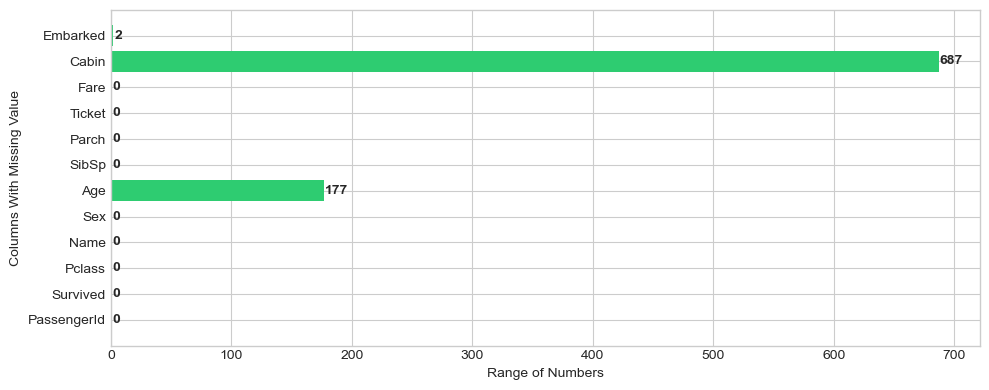

In [10]:
fig, ax = plt.subplots(figsize = (10,4))
ax.barh(train_df.columns, train_df.isnull().sum(), color='#2ecc71')
ax.set_xlabel("Range of Numbers")
ax.set_ylabel("Columns With Missing Value")
for i ,v in enumerate(train_df.isnull().sum()):
    #if v > 0:
        ax.text(v + 1, i, str(v), va='center', fontweight='bold')
#ax.text()
plt.tight_layout()
plt.show()

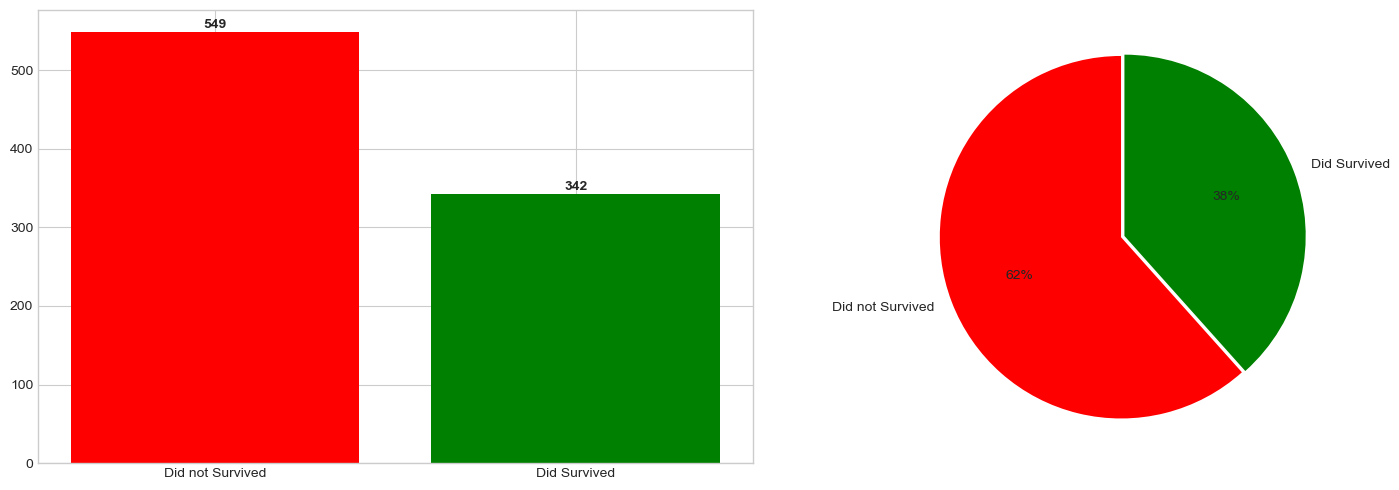


Survival rate : 38.38%

Survival rate : 61.62%


In [11]:
survive_count = train_df["Survived"].value_counts()

fig , ax = plt.subplots(1, 2 , figsize=(15,5))
ax[0].bar(["Did not Survived","Did Survived"], survive_count.values, color = ['red', 'green'])
for i ,v in enumerate(survive_count.values):
     ax[0].text(i,v+ 5, str(v), ha='center', fontweight='bold')

ax[1].pie(survive_count.values, labels=["Did not Survived","Did Survived"], colors = ['red', 'green'], startangle=90, explode=(0.01, 0.01), autopct='%1.0f%%')

plt.tight_layout()
plt.show()

print(f"\nSurvival rate : {train_df['Survived'].mean():.2%}")
print(f"\nSurvival rate : {1 - train_df['Survived'].mean():.2%}")

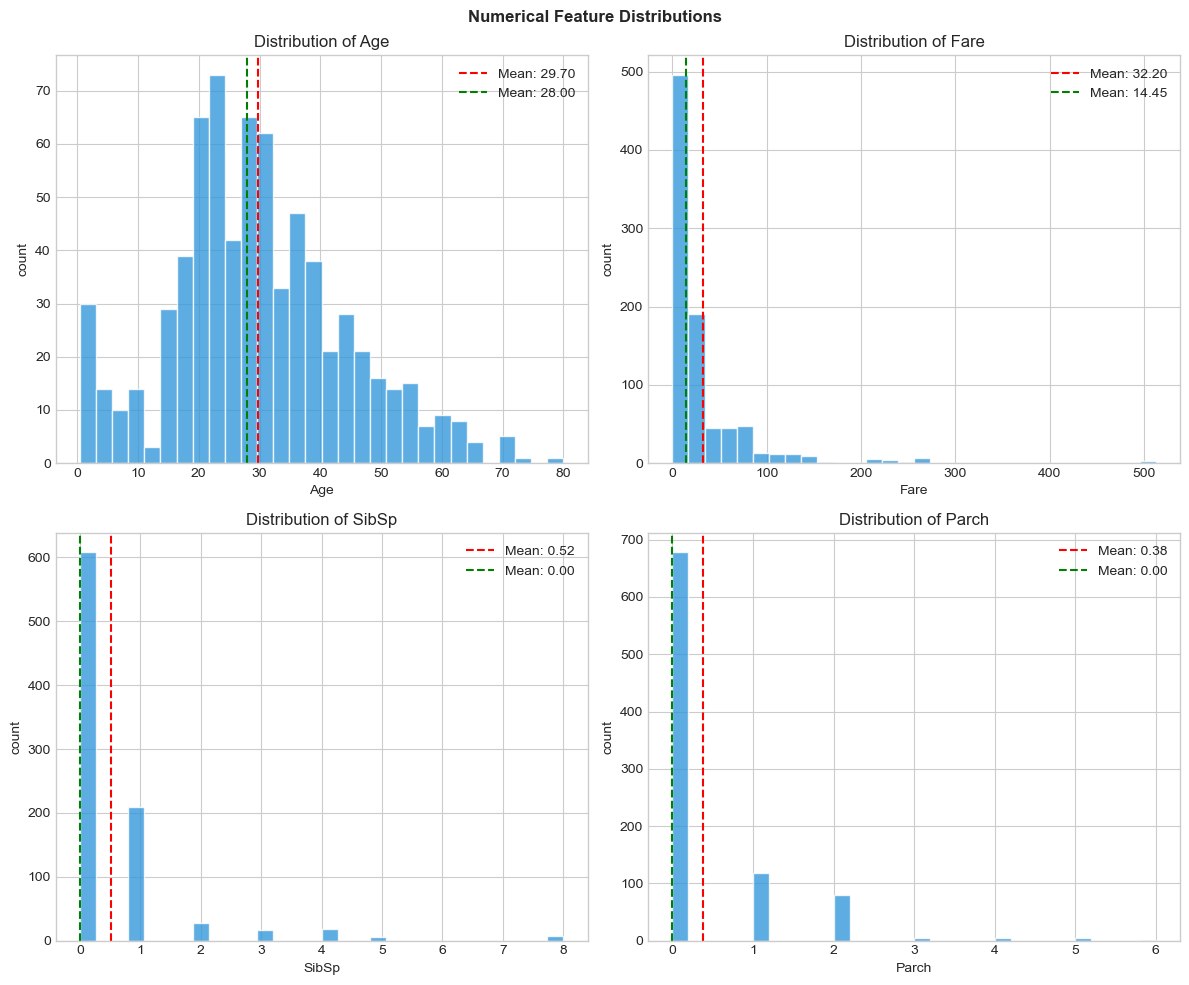

In [12]:
num_cols = ["Age", 'Fare', 'SibSp', 'Parch']

fig ,axes = plt.subplots(2,2 , figsize=(12, 10))
axes = axes.flatten()

for i ,col in enumerate(num_cols):
    axes[i].hist(train_df[col], bins=30, color= '#3498db', edgecolor='white', alpha =0.8)
    axes[i].axvline(train_df[col].mean(), c='red', linestyle= '--', label= f"Mean: {train_df[col].mean():.2f}")
    axes[i].axvline(train_df[col].median(), c='green', linestyle= '--', label= f"Mean: {train_df[col].median():.2f}")

    axes[i].set_title(f"Distribution of {col}", )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontweight="bold")
plt.tight_layout()
plt.show()

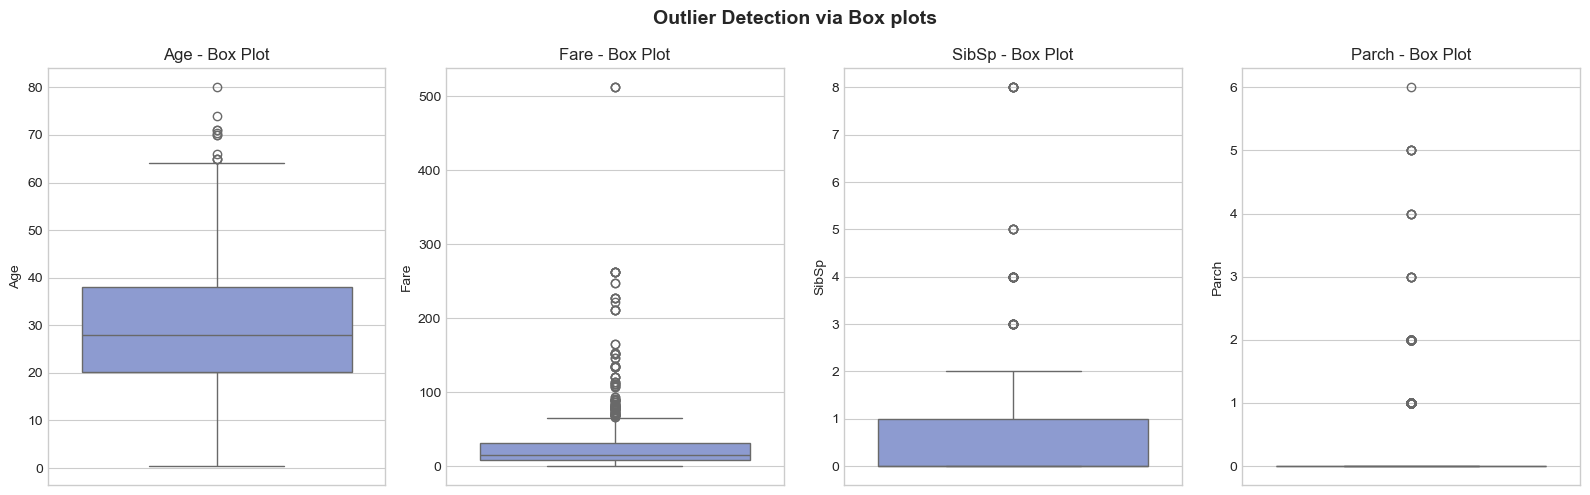

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16,5))

for i ,col in enumerate(num_cols):
    sns.boxplot(y = train_df[col], ax =axes[i], color='#8294db')
    axes[i].set_title(f"{col} - Box Plot")

plt.suptitle('Outlier Detection via Box plots', fontsize= 14, fontweight='bold')
plt.tight_layout()
plt.show()

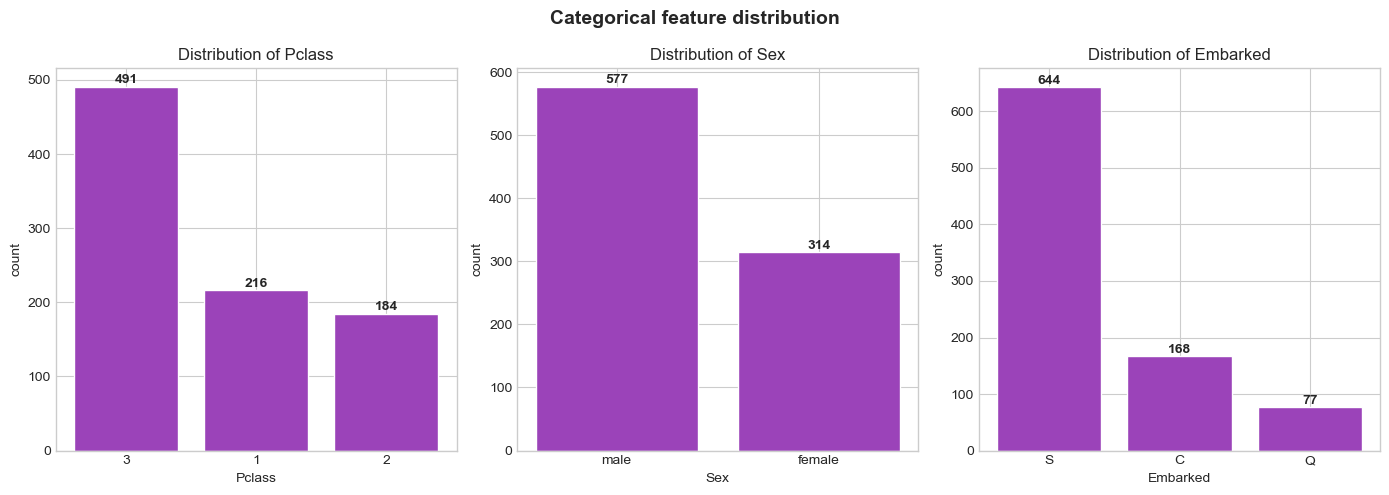

In [14]:
cat_cols = ['Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    counts = train_df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, edgecolor='white',color='#9b43b9')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

    for j, v in enumerate(counts.values):
        axes[i].text( j, v+ 5, str(v), ha='center', fontweight= 'bold')
        
    

plt.suptitle("Categorical feature distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

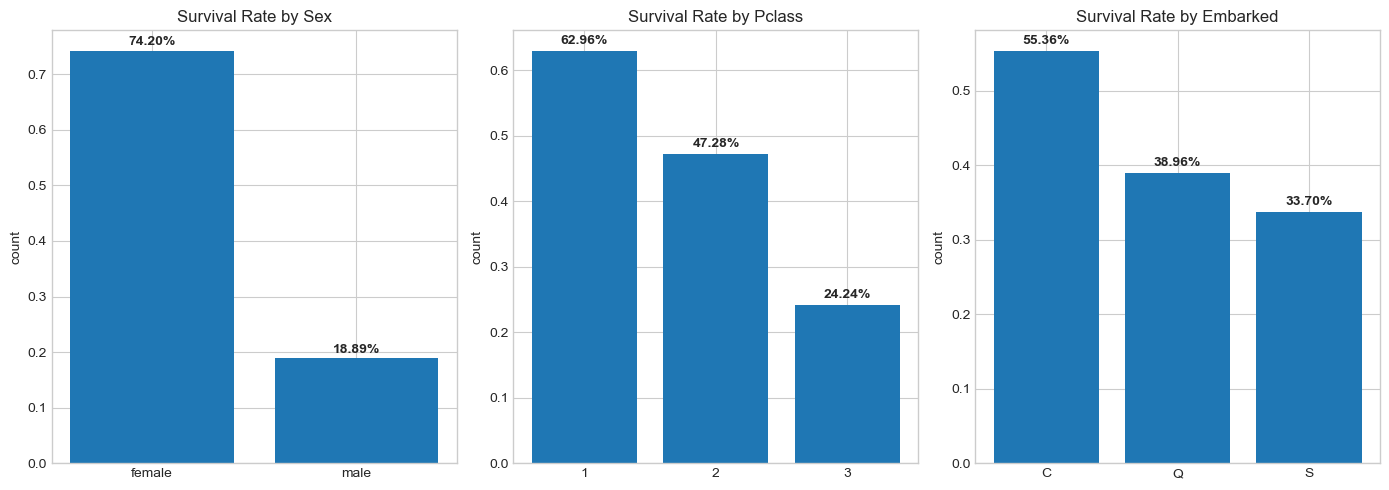

In [15]:
cat_cols = [ 'Sex','Pclass', 'Embarked']

fig,axes = plt.subplots(1,3 ,figsize= (14, 5))
for i, col in enumerate(cat_cols):
    survived_by_ = train_df.groupby(col)["Survived"].mean()
    axes[i].bar(survived_by_.index.astype(str), survived_by_.values,)
    axes[i].set_title(f"Survival Rate by {col}")
    axes[i].set_ylabel('count')

    for j, v in enumerate(survived_by_):
        axes[i].text(j, v + 0.01,f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

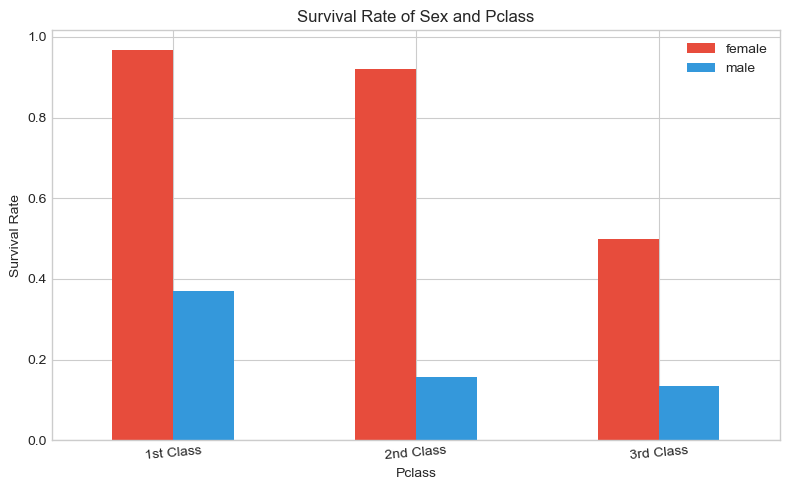

In [16]:
fig, ax = plt.subplots(figsize=(8,5))

survived_group = train_df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
survived_group.plot(kind='bar', ax=ax, color=["#e74c3c", "#3498db"])
ax.set_title("Survival Rate of Sex and Pclass")
ax.set_ylabel('Survival Rate')
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=5)
ax.legend()
plt.tight_layout()
plt.show()

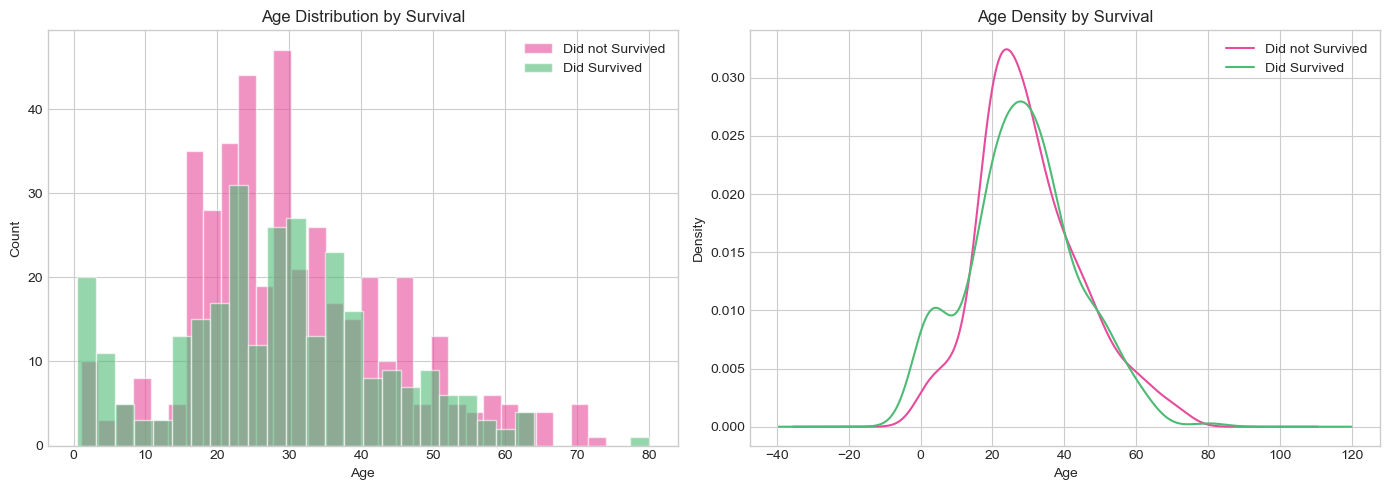

In [17]:
plt.style.use('seaborn-v0_8-pastel')

fig, axes = plt.subplots(1,2, figsize=(14, 5))

axes[0].hist(train_df[train_df["Survived"] == 0]['Age'].dropna(), label= 'Did not Survived',color='#e74c9c' , bins=30 , edgecolor='white', alpha=0.6)
axes[0].hist(train_df[train_df["Survived"] == 1]['Age'].dropna(), label= 'Did Survived' , color='#4ebb75',bins=30, edgecolor='white',alpha= 0.6)
axes[0].set_title("Age Distribution by Survival")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

train_df[train_df["Survived"]== 0]['Age'].plot.kde(ax=axes[1], color='#e74c9c', label= 'Did not Survived',)
train_df[train_df["Survived"]== 1]['Age'].plot.kde(ax=axes[1], color='#4ebb75', label= 'Did Survived',)
axes[1].set_title("Age Density by Survival")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()

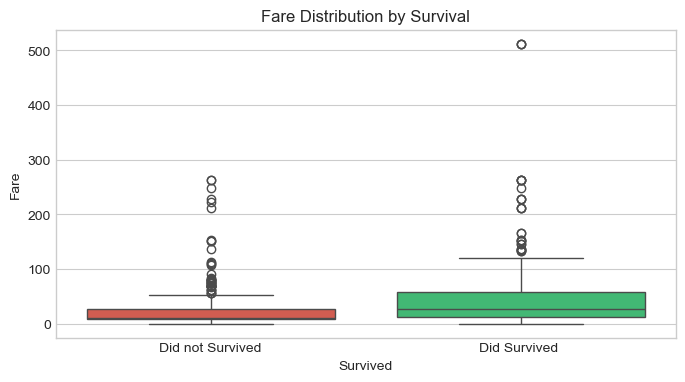

Average Fare -- Did Not Survived : 22.12$
Average Fare -- Did Survived  : 48.40$


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(x='Survived', y= 'Fare', data=train_df, palette = ["#e74c3c", "#2ecc71"], ax= ax)
ax.set_xticklabels(['Did not Survived', "Did Survived "])
ax.set_title("Fare Distribution by Survival")
ax.set_ylabel("Fare")

plt.show()

print(f"Average Fare -- Did Not Survived : {train_df[train_df['Survived'] == 0]['Fare'].mean():.2f}$")
print(f"Average Fare -- Did Survived  : {train_df[train_df['Survived'] == 1]['Fare'].mean():.2f}$")

<function matplotlib.pyplot.show(close=None, block=None)>

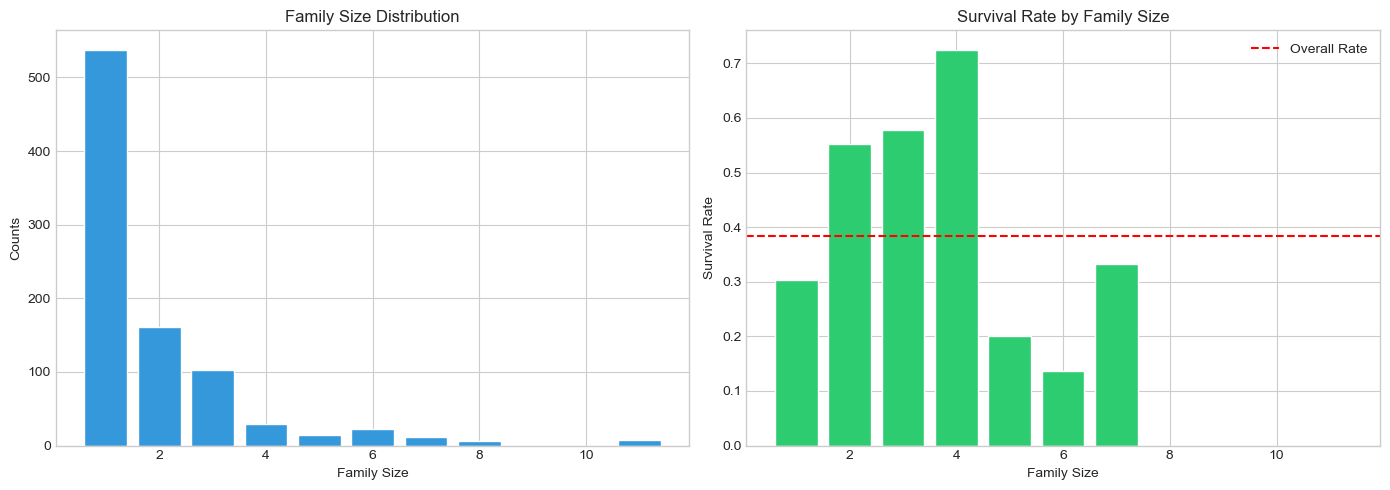

In [19]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

family_count = train_df['FamilySize'].value_counts()
axes[0].bar(family_count.index, family_count.values, color="#3498db", edgecolor="white")
axes[0].set_title("Family Size Distribution")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Counts")

survival_by_family = train_df.groupby("FamilySize")["Survived"].mean()
axes[1].bar(survival_by_family.index, survival_by_family.values, color="#2ecc71", edgecolor="white")
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Survival Rate")
axes[1].axhline(y = train_df['Survived'].mean(), color='red', linestyle='--', label= 'Overall Rate')
axes[1].legend()

plt.tight_layout()
plt.show

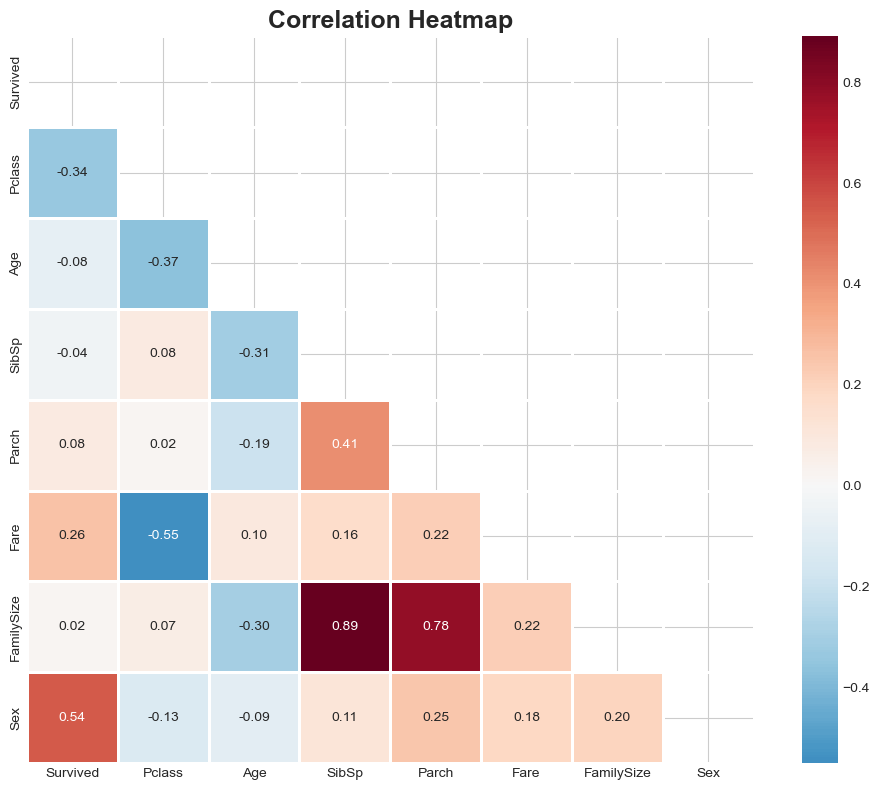

In [20]:
num_df = train_df[['Survived','Pclass','Age','SibSp','Parch','Fare', 'FamilySize']].copy()
num_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,ax=ax, annot= True, mask=mask, cmap='RdBu_r', center =0 , square= True, linewidth= 1, fmt='.2f')
ax.set_title('Correlation Heatmap', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

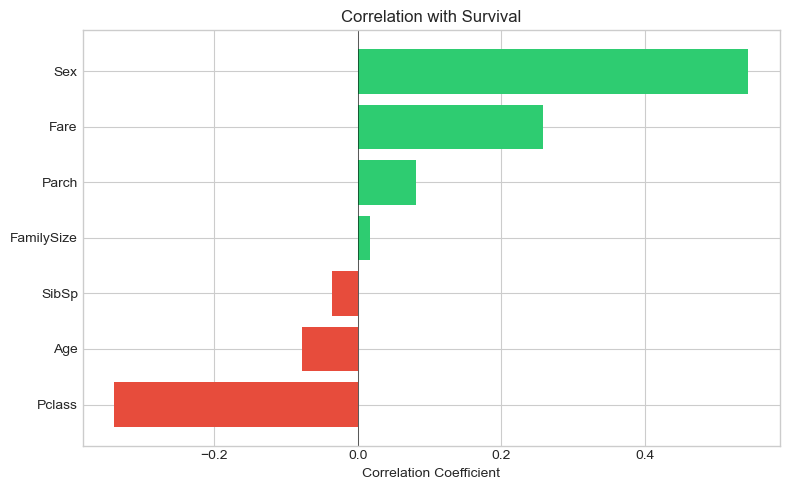

In [21]:
target_corr = corr['Survived'].drop("Survived").sort_values(ascending=True)

fi, ax = plt.subplots(figsize=(8,5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values,color = colors)
ax.set_title("Correlation with Survival")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x= 0, color='black', linewidth=0.4)

plt.tight_layout()
plt.show()

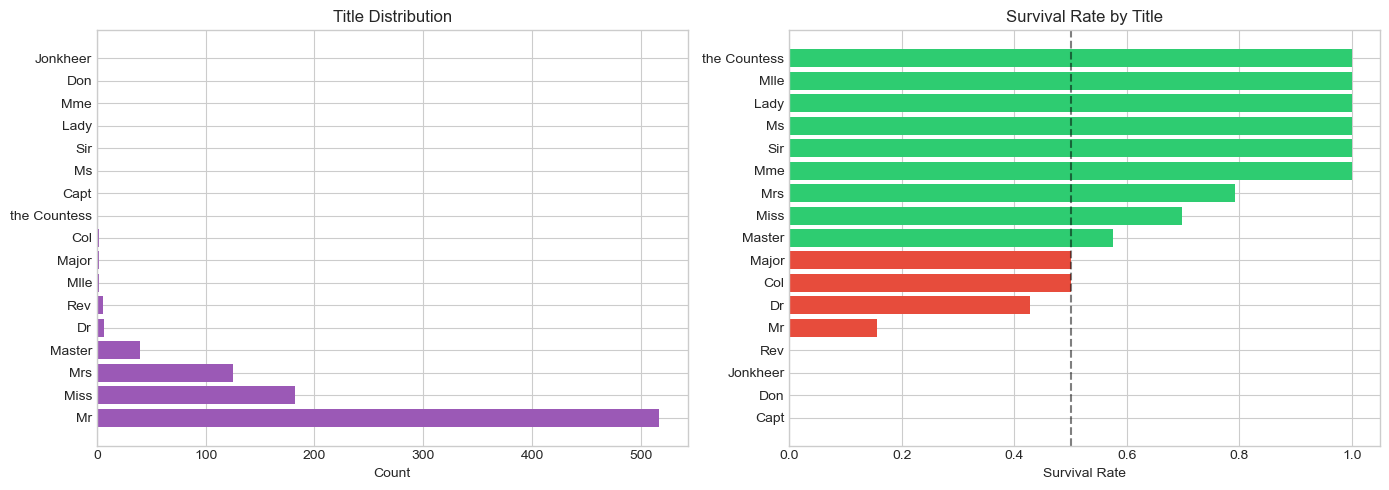

In [22]:
train_df['Title'] = train_df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

title_counts= train_df["Title"].value_counts()
axes[0].barh(title_counts.index, title_counts.values, color="#9b59b6")
axes[0].set_title("Title Distribution")
axes[0].set_xlabel("Count")

survival_by_title = train_df.groupby('Title')['Survived'].mean().sort_values()
colors = ["#2ecc71" if v > 0.5 else "#e74c3c" for v in survival_by_title.values]
axes[1].barh(survival_by_title.index, survival_by_title.values, color=colors)
axes[1].set_title("Survival Rate by Title")
axes[1].set_xlabel("Survival Rate")
axes[1].axvline(x=0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()